In [2]:
!pip install -q transformers datasets torch sentencepiece gitpython


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import json
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/Export.json")
assert DATA_PATH.exists(), "❌ JSON file not found"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    bugs = json.load(f)

print("✅ Total bugs loaded:", len(bugs))
print("Languages in dataset:", set(bug['lang'] for bug in bugs))


✅ Total bugs loaded: 3947
Languages in dataset: {'Python', 'Java'}


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from datasets import Dataset

dataset = Dataset.from_list(pairs)
dataset = dataset.train_test_split(test_size=0.1, seed=42)

print(dataset)


DatasetDict({
    train: Dataset({
        features: [],
        num_rows: 0
    })
    test: Dataset({
        features: [],
        num_rows: 0
    })
})


In [8]:
diff_url = bugs[0]["diff_url"]
print("First diff URL:", diff_url)


First diff URL: https://github.com/gwtbootstrap3/gwtbootstrap3/compare/eb7b4f991d67017538569e02b25f962af42aecac..41d93b14bf4c8ba2ae75d561ad3a640319e5a4ce


In [9]:
import requests

response = requests.get(diff_url, timeout=10)
response.raise_for_status()

diff_text = response.text
print(diff_text[:1000])  # preview first 1000 characters









<!DOCTYPE html>
<html
  lang="en"
  
  data-color-mode="auto" data-light-theme="light" data-dark-theme="dark"
  data-a11y-animated-images="system" data-a11y-link-underlines="true"
  
  >




  <head>
    <meta charset="utf-8">
  <link rel="dns-prefetch" href="https://github.githubassets.com">
  <link rel="dns-prefetch" href="https://avatars.githubusercontent.com">
  <link rel="dns-prefetch" href="https://github-cloud.s3.amazonaws.com">
  <link rel="dns-prefetch" href="https://user-images.githubusercontent.com/">
  <link rel="preconnect" href="https://github.githubassets.com" crossorigin>
  <link rel="preconnect" href="https://avatars.githubusercontent.com">

  

  <link crossorigin="anonymous" media="all" rel="stylesheet" href="https://github.githubassets.com/assets/light-dac525bbd821.css" /><link crossorigin="anonymous" media="all" rel="stylesheet" href="https://github.githubassets.com/assets/light_high_contrast-56ccf4057897.css" /><link crossorigin="anonymous" media="all" rel=

In [10]:
def to_patch_url(diff_url):
    if diff_url.endswith(".patch") or diff_url.endswith(".diff"):
        return diff_url
    return diff_url + ".patch"


In [11]:
def parse_diff_to_pair(diff):
    buggy_lines, fixed_lines = [], []

    for line in diff.splitlines():
        # skip metadata
        if line.startswith(("diff ", "index ", "@@", "---", "+++")):
            continue

        if line.startswith("-") and not line.startswith("--"):
            buggy_lines.append(line[1:])
        elif line.startswith("+") and not line.startswith("++"):
            fixed_lines.append(line[1:])

    buggy = "\n".join(buggy_lines).strip()
    fixed = "\n".join(fixed_lines).strip()
    return buggy, fixed


In [12]:
import requests
from tqdm import tqdm
import json
from pathlib import Path

# Ensure DATA_PATH and bugs are defined in this cell
DATA_PATH = Path("/content/drive/MyDrive/Export.json")

# Attempt to load bugs, handling potential FileNotFoundError
try:
    if not DATA_PATH.exists():
        print(f"❌ Error: JSON file not found at {DATA_PATH}. Please ensure your Google Drive is mounted (cell s93xxuM0rdo6) and the file exists.")
        bugs = [] # Initialize as empty to prevent further errors
    else:
        with open(DATA_PATH, "r", encoding="utf-8") as f:
            bugs = json.load(f)
except Exception as e:
    print(f"❌ Error loading bugs data: {e}")
    bugs = []

pairs = []

for bug in tqdm(bugs, desc="Downloading GitHub patches"):
    if bug["lang"] != "Java":  # or "Python"
        continue

    raw_url = bug.get("diff_url")
    if not raw_url:
        continue

    # to_patch_url and parse_diff_to_pair are assumed to be defined in previously executed cells
    patch_url = to_patch_url(raw_url)

    try:
        resp = requests.get(patch_url, timeout=10)
        resp.raise_for_status()

        buggy, fixed = parse_diff_to_pair(resp.text)

        if buggy and fixed:
            pairs.append({
                "buggy": buggy,
                "fixed": fixed
            })

    except Exception: # silent skip is fine here, as per original code
        continue

print("✅ Total extracted repair pairs:", len(pairs))

✅ Total extracted repair pairs: 1813


In [13]:
import requests
from tqdm import tqdm

pairs = []

for bug in tqdm(bugs, desc="Downloading GitHub patches"):
    if bug["lang"] != "Java":  # or "Python"
        continue

    raw_url = bug.get("diff_url")
    if not raw_url:
        continue

    patch_url = to_patch_url(raw_url)

    try:
        resp = requests.get(patch_url, timeout=10)
        resp.raise_for_status()

        buggy, fixed = parse_diff_to_pair(resp.text)

        if buggy and fixed:
            pairs.append({
                "buggy": buggy,
                "fixed": fixed
            })

    except Exception:
        continue  # silent skip is fine here

print("✅ Total extracted repair pairs:", len(pairs))


✅ Total extracted repair pairs: 1813


In [14]:
print("Type of bugs:", type(bugs))
print("Length of bugs:", len(bugs))


Type of bugs: <class 'list'>
Length of bugs: 3947


In [15]:
import json
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/Export.json")

assert DATA_PATH.exists(), "❌ Export.json not found"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    bugs = json.load(f)

print("✅ Reloaded bugs:", len(bugs))


✅ Reloaded bugs: 3947


In [16]:
assert len(bugs) > 0, "❌ bugs list is empty — STOP"


In [17]:
bugs[0]


{'image_tag': 'gwtbootstrap3-gwtbootstrap3-92837490',
 'lang': 'Java',
 'metrics': {'changes': 79},
 'reproducibility_status': {'status': 'Reproducible'},
 'failed_job': {'job_id': 92837490,
  'build_id': 92837489,
  'num_tests_run': 16,
  'num_tests_failed': 0,
  'trigger_sha': 'eb7b4f991d67017538569e02b25f962af42aecac'},
 'passed_job': {'trigger_sha': '41d93b14bf4c8ba2ae75d561ad3a640319e5a4ce'},
 'classification': {'build': 'Yes',
  'code': 'No',
  'exceptions': [],
  'test': 'No'},
 'diff_url': 'https://github.com/gwtbootstrap3/gwtbootstrap3/compare/eb7b4f991d67017538569e02b25f962af42aecac..41d93b14bf4c8ba2ae75d561ad3a640319e5a4ce',
 'repo': 'gwtbootstrap3/gwtbootstrap3',
 'ci_service': 'travis'}

In [18]:
import requests

test_bug = bugs[0]
patch_url = test_bug["diff_url"] + ".patch"

print("Patch URL:", patch_url)

r = requests.get(patch_url, timeout=10)
print("HTTP status:", r.status_code)
print(r.text[:500])


Patch URL: https://github.com/gwtbootstrap3/gwtbootstrap3/compare/eb7b4f991d67017538569e02b25f962af42aecac..41d93b14bf4c8ba2ae75d561ad3a640319e5a4ce.patch
HTTP status: 200
From 41d93b14bf4c8ba2ae75d561ad3a640319e5a4ce Mon Sep 17 00:00:00 2001
From: Steven Jardine <steve@mjnservices.com>
Date: Mon, 23 Nov 2015 17:29:52 -0700
Subject: [PATCH] Updated pom.xml

---
 pom.xml | 79 ++++++++++++++++++++-------------------------------------
 1 file changed, 28 insertions(+), 51 deletions(-)

diff --git a/pom.xml b/pom.xml
index fd9c25d6f..e342b5ec0 100644
--- a/pom.xml
+++ b/pom.xml
@@ -1,5 +1,6 @@
 <?xml version="1.0" encoding="UTF-8"?>
-<project xmlns="http://maven.apach


In [19]:
from tqdm import tqdm
import requests

pairs = []

for bug in tqdm(bugs, desc="Downloading GitHub patches"):
    if bug.get("lang") != "Java":   # or "Python"
        continue

    diff_url = bug.get("diff_url")
    if not diff_url:
        continue

    try:
        r = requests.get(diff_url + ".patch", timeout=10)
        if r.status_code != 200:
            continue

        buggy_lines, fixed_lines = [], []

        for line in r.text.splitlines():
            if line.startswith(("diff ", "index ", "@@", "---", "+++")):
                continue
            if line.startswith("-") and not line.startswith("--"):
                buggy_lines.append(line[1:])
            elif line.startswith("+") and not line.startswith("++"):
                fixed_lines.append(line[1:])

        if buggy_lines and fixed_lines:
            pairs.append({
                "buggy": "\n".join(buggy_lines),
                "fixed": "\n".join(fixed_lines)
            })

    except Exception:
        continue

print("✅ Total extracted repair pairs:", len(pairs))


✅ Total extracted repair pairs: 1816


In [20]:
from datasets import Dataset

dataset = Dataset.from_list(pairs)
dataset = dataset.train_test_split(test_size=0.1, seed=42)

print(dataset)


DatasetDict({
    train: Dataset({
        features: ['buggy', 'fixed'],
        num_rows: 1634
    })
    test: Dataset({
        features: ['buggy', 'fixed'],
        num_rows: 182
    })
})


In [21]:
!pip install -q transformers accelerate sentencepiece datasets


In [22]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments
)


In [23]:
MODEL_NAME = "Salesforce/codet5-small"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print("✅ Model loaded")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/242M [00:00<?, ?B/s]

✅ Model loaded


In [24]:
MAX_LEN = 256

def tokenize(batch):
    inputs = tokenizer(
        batch["buggy"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

    labels = tokenizer(
        batch["fixed"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

    inputs["labels"] = labels["input_ids"]
    return inputs


In [25]:
tokenized_ds = dataset.map(
    tokenize,
    batched=True
)


Map:   0%|          | 0/1634 [00:00<?, ? examples/s]

Map:   0%|          | 0/182 [00:00<?, ? examples/s]

In [26]:
print(tokenized_ds)


DatasetDict({
    train: Dataset({
        features: ['buggy', 'fixed', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 1634
    })
    test: Dataset({
        features: ['buggy', 'fixed', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 182
    })
})


In [28]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./apr_model",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-5,
    num_train_epochs=3,
    fp16=torch.cuda.is_available(),
    logging_steps=100,
    save_steps=500,
    save_total_limit=2,
    report_to="none"
)

print("✅ training_args ready")


✅ training_args ready


In [30]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

print("✅ data_collator ready")


✅ data_collator ready


In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    tokenizer=tokenizer,
    data_collator=data_collator
)

print("✅ Trainer initialized")


✅ Trainer initialized


/tmp/ipython-input-745618789.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [32]:
trainer.train()


Step,Training Loss
100,2.065500
200,1.336300
300,1.229800


TrainOutput(global_step=309, training_loss=1.5278026679572936, metrics={'train_runtime': 176.4688, 'train_samples_per_second': 27.778, 'train_steps_per_second': 1.751, 'total_flos': 331722755407872.0, 'train_loss': 1.5278026679572936, 'epoch': 3.0})

In [33]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
SAVE_PATH = "/content/drive/MyDrive/apr_codet5_bugswarm"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("✅ Model saved to Drive")


✅ Model saved to Drive


In [35]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model = AutoModelForSeq2SeqLM.from_pretrained(SAVE_PATH)
tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)

model.to("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Model reloaded")


✅ Model reloaded


In [36]:
def repair_code(buggy_code):
    inputs = tokenizer(
        buggy_code,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_length=256,
        num_beams=5,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [37]:
sample = dataset["test"][0]["buggy"]

print("🐞 BUGGY CODE:\n", sample)
print("\n🛠️ MODEL FIX:\n", repair_code(sample))


🐞 BUGGY CODE:
         assertEquals(bean.v03.getTime(), bean1.v03.getTime());

🛠️ MODEL FIX:
         assertEquals(bean.v03.getTime(), bean1.v03.getTime());


In [38]:
!pip install -q sacrebleu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.5 MB/s eta 0:00:00


In [40]:
print("Test dataset length:", len(dataset["test"]))
print("First item:", dataset["test"][0])


Test dataset length: 182
First item: {'buggy': '        assertEquals(bean.v03.getTime(), bean1.v03.getTime());', 'fixed': '        assertEquals(bean.v03.getYear(), bean1.v03.getYear());'}


In [42]:
# Get rows properly
test_rows = dataset["test"]

predictions = []
references = []

for i in range(min(50, len(test_rows))):
    buggy_code = test_rows[i]["buggy"]
    fixed_code = test_rows[i]["fixed"]

    # Use your model prediction
    pred = repair_code(buggy_code)
    predictions.append(pred)
    references.append([fixed_code])

import sacrebleu
bleu = sacrebleu.corpus_bleu(predictions, references)
print("📊 BLEU score:", bleu.score)


📊 BLEU score: 90.19363707157844


In [46]:
# Re-run this block to make sure predictions and references are defined
predictions = []
references = []

test_rows = dataset["test"]

for i in range(min(50, len(test_rows))):
    buggy_code = test_rows[i]["buggy"]
    fixed_code = test_rows[i]["fixed"]

    pred = repair_code(buggy_code)  # make sure repair_code function is defined
    predictions.append(pred)
    references.append([fixed_code])

print("Predictions length:", len(predictions))
print("References length:", len(references))


Predictions length: 50
References length: 50


In [47]:
if len(predictions) == 0:
    print("Predictions list is empty! Re-run the prediction loop first.")
else:
    print("Ready to plot!")


Ready to plot!


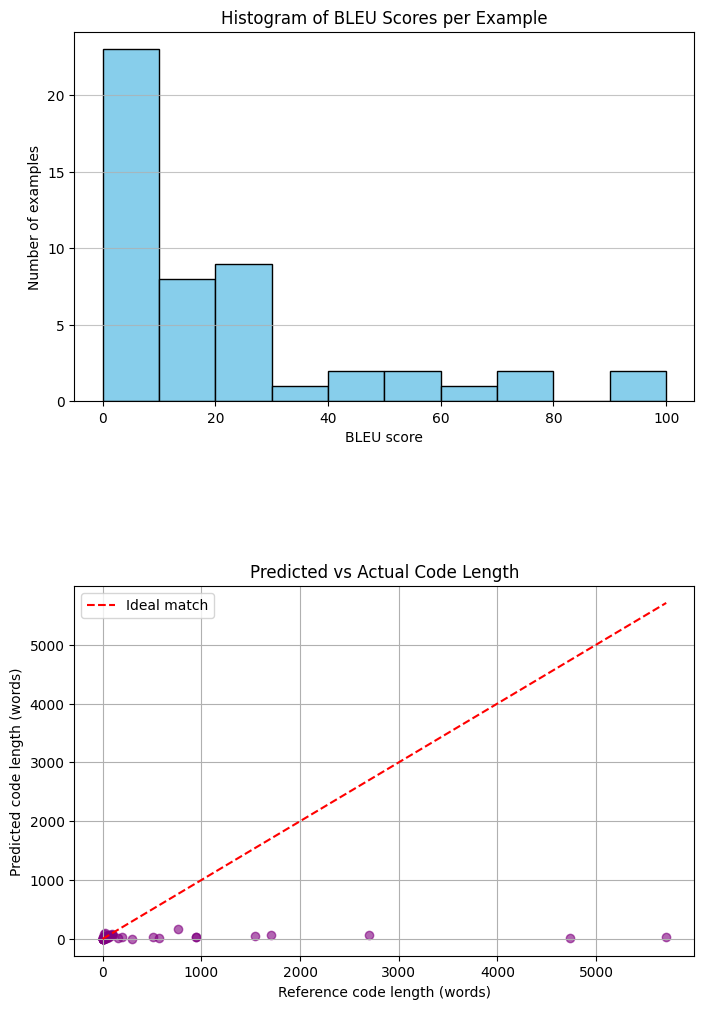

In [53]:
import matplotlib.pyplot as plt
import sacrebleu
import numpy as np


if len(predictions) == 0:
    raise ValueError("Predictions list is empty! Re-run the prediction loop first.")

bleu_scores = [sacrebleu.sentence_bleu(pred, ref_list).score for pred, ref_list in zip(predictions, references)]

pred_lengths = [len(pred.split()) for pred in predictions]
ref_lengths = [len(ref_list[0].split()) for ref_list in references]




fig, axs = plt.subplots(2, 1, figsize=(8, 12))
plt.subplots_adjust(hspace=0.5)

# Plot 1: Histogram of BLEU Scores
axs[0].hist(bleu_scores, bins=10, color='skyblue', edgecolor='black')
axs[0].set_title("Histogram of BLEU Scores per Example")
axs[0].set_xlabel("BLEU score")
axs[0].set_ylabel("Number of examples")
axs[0].grid(axis='y', alpha=0.75)

# Plot 2: Predicted vs Actual Code Length
axs[1].scatter(ref_lengths, pred_lengths, alpha=0.6, color='purple')
max_len = max(ref_lengths + pred_lengths) + 2
axs[1].plot([0, max_len], [0, max_len], 'r--', label="Ideal match")
axs[1].set_title("Predicted vs Actual Code Length")
axs[1].set_xlabel("Reference code length (words)")
axs[1].set_ylabel("Predicted code length (words)")
axs[1].legend()
axs[1].grid(True)

plt.show()


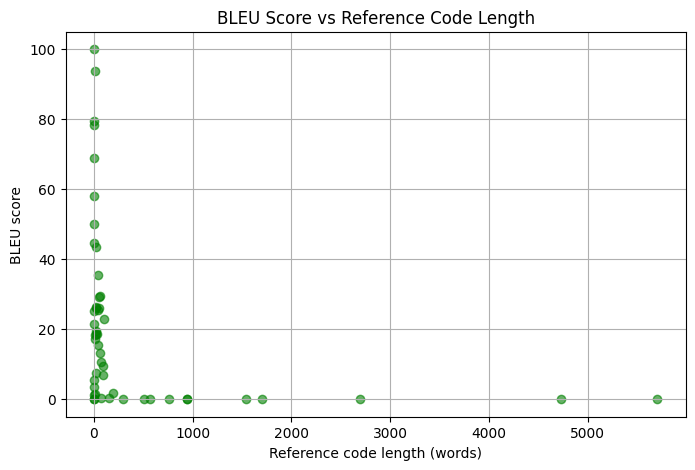

In [54]:
plt.figure(figsize=(8,5))
plt.scatter([len(ref[0].split()) for ref in references], bleu_scores, color='green', alpha=0.6)
plt.title("BLEU Score vs Reference Code Length")
plt.xlabel("Reference code length (words)")
plt.ylabel("BLEU score")
plt.grid(True)
plt.show()


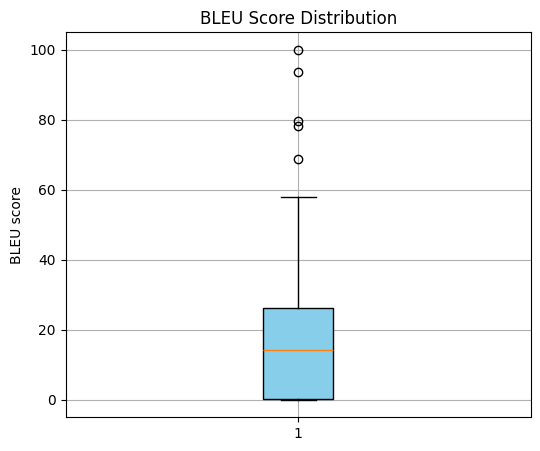

In [56]:
plt.figure(figsize=(6,5))
plt.boxplot(bleu_scores, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title("BLEU Score Distribution")
plt.ylabel("BLEU score")
plt.grid(True)
plt.show()


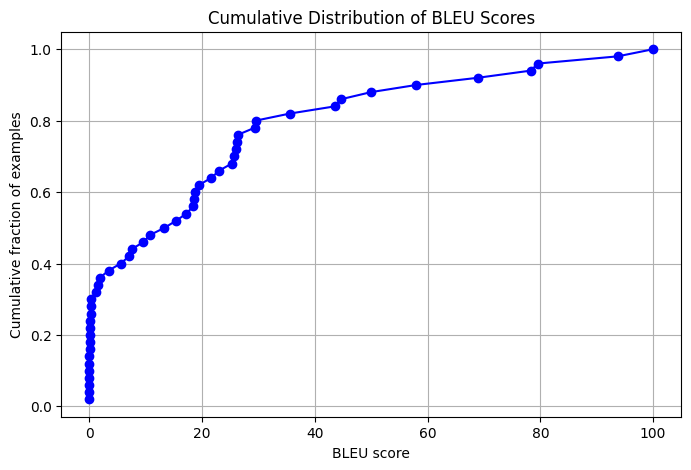

In [57]:
plt.figure(figsize=(8,5))
sorted_bleu = np.sort(bleu_scores)
cdf = np.arange(1, len(sorted_bleu)+1) / len(sorted_bleu)
plt.plot(sorted_bleu, cdf, marker='o', linestyle='-', color='blue')
plt.title("Cumulative Distribution of BLEU Scores")
plt.xlabel("BLEU score")
plt.ylabel("Cumulative fraction of examples")
plt.grid(True)
plt.show()
